In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from RENDES_fizinfo import *

In [2]:
auto_raw = GPS_to_num_kinem('Gyor-Bodajk.csv', orig='first')
auto = num_kinem_smooth_r(auto_raw, 0.1, lam=50, err_report=True)
#auto.plot_rcomp()
auto.full_kinem_calc()

Adatsor pontosság: RMS=5.813; MAX=11.000
Eltérés          : RMS=1.120; MAX=6.780


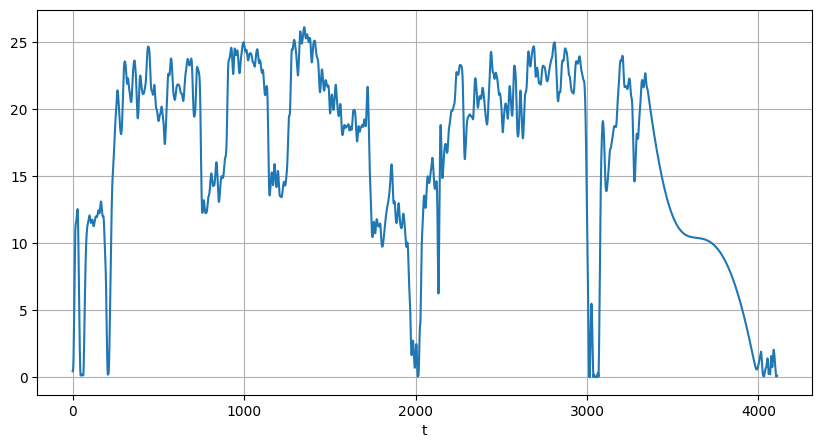

In [3]:
# a) Ábrázolja a auto sebességének nagyságát az idő függvényében! 2p

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(auto.t,auto.v_abs)
ax1.set_xlabel('t')

ax1.grid()

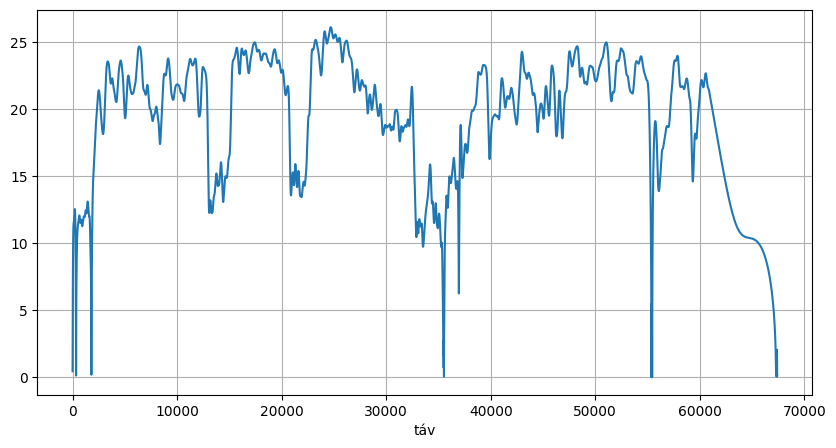

In [4]:
# a) Ábrázolja a auto sebességének nagyságát az útvonalhossz függvényében! 2p

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(auto.pathlength,auto.v_abs)
ax1.set_xlabel('táv')

ax1.grid()

In [5]:
# b) A menetidő és az út hány százalékát töltötte az autó 65 km/h-nál nagyobb sebességgel? (4 p)
v_kuszob = 65 / 3.6 # km/h to m/s

dr = auto.pathlength[1:] - auto.pathlength[:-1] # lépésköz, azaz mennyi idő telt el két egymást követő mérés között

dt = auto.t[1:] - auto.t[:-1] # lépésköz, azaz mennyi idő telt el két egymást követő mérés között

auto_gyorsabb_mint_65kmh = auto.v_abs[:-1] > v_kuszob # bool tömb maszk, hol igaz, hogy v < 1m/s

auto_gyorsabb_mint_65kmh_ossz_ido = dt[auto_gyorsabb_mint_65kmh].sum()
auto_gyorsabb_mint_65kmh_ossz_tav = dr[auto_gyorsabb_mint_65kmh].sum()

print(f'Az auto a tav {auto_gyorsabb_mint_65kmh_ossz_tav / auto.pathlength[-1] * 100:.2f}% ban ment többel mint 65km/h' )
print(f'Az auto az ido {auto_gyorsabb_mint_65kmh_ossz_ido / auto.t[-1] * 100:.2f}% ban ment többel mint 65km/h' )



Az auto a tav 71.24% ban ment többel mint 65km/h
Az auto az ido 53.75% ban ment többel mint 65km/h


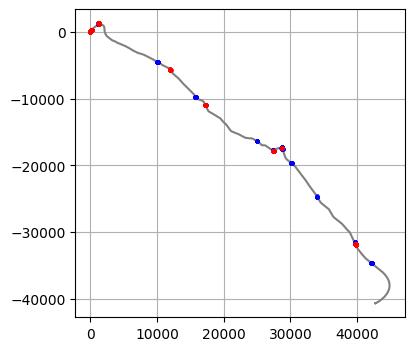

In [6]:
# c) Készítsen ábrát, melyen az autó pályája szürke, és rajta pirossal az erős gyorsítási (0.5 m/s^2-nél
# erősebb), kékkel az erős fékezési (0.5 m/s^2-nél erősebb) szakaszok vannak bejelölve! (4 p)

eros_gyors_kuszob = 0.5   # m/s^2, erős gyors küszöbe
eros_fekezes_kuszob = 0.5   # m/s^2, erős fekezes küszöbe

eros_gyors = auto.a_t_abs > eros_gyors_kuszob   # bool maszk: erős tangenciális gyorsulás
eros_fekezes = -auto.a_t_abs > eros_fekezes_kuszob   # bool maszk: erős fékezés (a_t negatív fékezésnél)

fig=plt.figure(figsize=(14,4))  
ax1=plt.subplot(111)

ax1.plot(auto.r[:,0], auto.r[:,1], color="grey")  # a pályagörbe
ax1.scatter(auto.r[eros_fekezes, 0], auto.r[eros_fekezes, 1],
            color='blue',  s=4, zorder=3)                     # erős fékezési szakaszok
ax1.scatter(auto.r[eros_gyors,  0], auto.r[eros_gyors,  1],
            color='red', s=4, zorder=3)                     # erős gyorsítasi szakaszok


ax1.set_aspect(aspect='equal')
ax1.grid()

In [7]:
# d) Határozza meg, mennyi időbe telt, amíg az autó megtette a teljes útvonal 25, 50 és 75%-át! (4 p)

ossz_tav = auto.pathlength[-1]
tav_25p = ossz_tav * 0.25
tav_50p = ossz_tav * 0.50
tav_75p = ossz_tav * 0.75

i_25 = arg_eq(auto.pathlength, tav_25p)  # index ahol pathlength eléri a 25%-ot
i_50 = arg_eq(auto.pathlength, tav_50p)  # index ahol pathlength eléri az 50%-ot
i_75 = arg_eq(auto.pathlength, tav_75p)  # index ahol pathlength eléri a 75%-ot

print(f'25% megtéve: {auto.t[i_25[0]]:.1f} s')
print(f'50% megtéve: {auto.t[i_50[0]]:.1f} s')
print(f'75% megtéve: {auto.t[i_75[0]]:.1f} s')


25% megtéve: 973.4 s
50% megtéve: 1822.7 s
75% megtéve: 2789.3 s
